# Gradiente Descendiente

## Regresión lineal con Gradiente Descendiente

Para entender este concepto, junto con el del optimización, recomiendo revisar el archivo "Optimizacion.ipynb" dentro de este mismo repositorio, ubicado en `/humai/04_Math_for_AI/Optimizacion`. Allí se explica en detalle el concepto del cual proviene el gradiente descendiente, su relación con las derivadas, cómo se calcula, etc.

Este notebook es solo un ejemplo más simple, en el cual intentaremos generar un modelo de regresión lineal "a mano" utilizando el gradiente descendiente y luego lo compararemos con la implementación propia de `scikit-learn`. 

A grandes rasgos, el gradiente descendiente no es otra cosa que un algoritmo iterativo que nos permite obtener los valores que nos brindan el mínimo de una función de costo.

En el caso de la regresión lineal, nuestra función de costo sería la función de error (el más utilizado es el error cuadrático medio o MSE). Lo que nos interesa es obtener los valores de $b$ ($b0$ que sería la ordenada al origen, $b1$ que sería el coeficiente 1, etc) que harán que el cálculo del error sea el mínimo posible.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [18]:
# Variable independiente
experiencia = np.array([[5], [6], [13]])

# Variable dependiente
salario = np.array([6.85, 16.83, 26.84])

modelo = LinearRegression().fit(experiencia, salario)

# Visualización de datos y modelo
print("Intersección con eje Y (b): %0.2f" % modelo.intercept_)
print("Pendiente (m): %0.2f" % modelo.coef_[0])
print("Suma de cuadrados de los residuos (RSS): %0.2f" %
      ((salario - modelo.predict(experiencia))**2).sum())
print("Error cuadrático medio (MSE): %0.2f" %
      (((salario - modelo.predict(experiencia))**2).sum() / experiencia.shape[0]))

mean_squared_error(salario, modelo.predict(experiencia))

Intersección con eje Y (b): 0.00
Pendiente (m): 2.10
Suma de cuadrados de los residuos (RSS): 31.42
Error cuadrático medio (MSE): 10.47


10.473749999999999

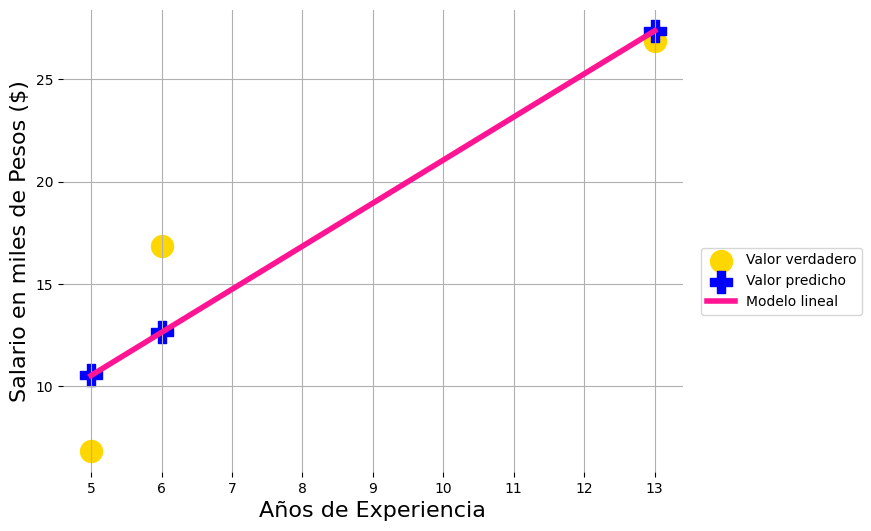

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(experiencia, salario, color="gold", s=250,
            marker="o", label="Valor verdadero")

plt.scatter(experiencia, modelo.predict(experiencia),
            color="blue", s=250, marker="P", label="Valor predicho") 

plt.plot(experiencia, modelo.predict(experiencia),
         linewidth=4, color="deeppink", label="Modelo lineal") 

experiencia = experiencia.reshape(3)

plt.ylabel("Salario en miles de Pesos ($)", size=16)
plt.xlabel("Años de Experiencia", size=16)
plt.legend(bbox_to_anchor=(1.3, 0.5))
plt.grid()
plt.box(False)
plt.show()

### Diferentes modelos con diferentes pendientes

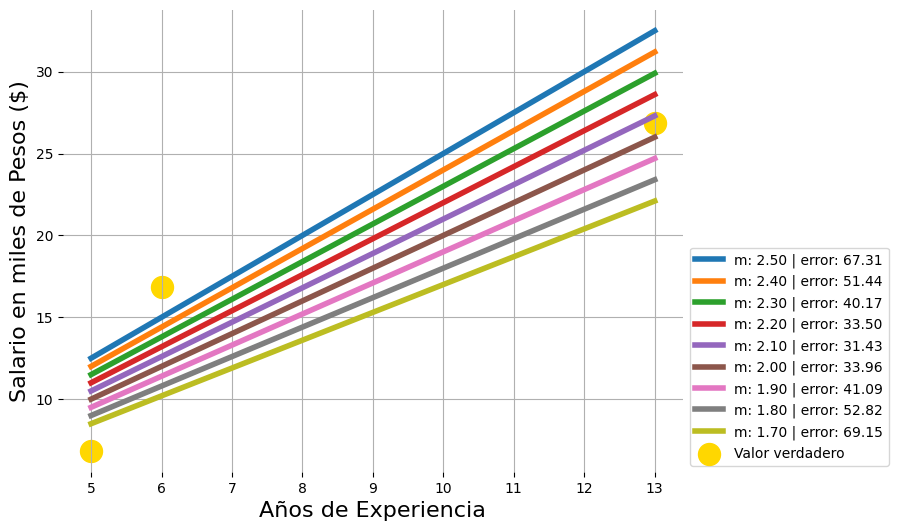

In [20]:
# Creación de múltiples pendientes para exploración
pendientes = np.arange(2.5, 1.6, -0.1)

# Vector para almacenar el error de los diferentes modelos
errores = np.array([])

# Visualización de modelos

plt.figure(figsize=(8, 6))

for pendiente in pendientes: 
    # Error del modelo (suma de cuadrados de los residuos)
    # recordar que para este ejemplo tenemos el b0 = 0 para simplicar el caso
    error = ((salario - pendiente*experiencia)**2).sum()

    # Visualización de un modelo para una pendiente dada
    plt.plot(experiencia, pendiente*experiencia, linewidth=4, 
             label="m: %0.2f | error: %0.2f" %
            (pendiente, error)) 
    
    errores = np.append(errores, error)

plt.scatter(experiencia, salario, color="gold", s=250,
            marker="o", label="Valor verdadero")

plt.ylabel("Salario en miles de Pesos ($)", size=16)
plt.xlabel("Años de Experiencia", size=16)
plt.legend(bbox_to_anchor=(1, 0.5))
plt.grid()
plt.box(False)
plt.show()

### Visualización de los errores

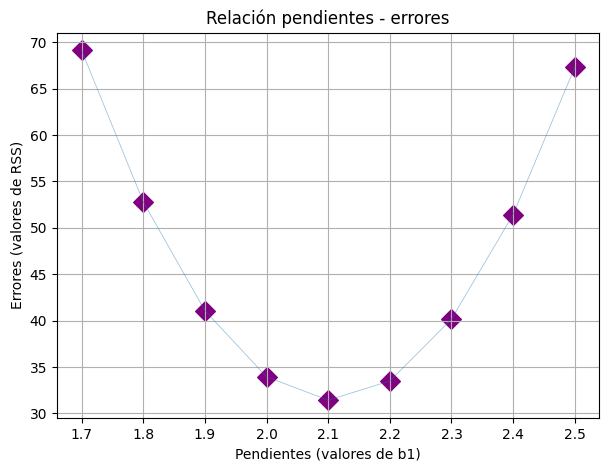

In [30]:
plt.figure(figsize=(7, 5))
plt.scatter(pendientes, errores, marker="D", color="purple", s=100)
plt.plot(pendientes, errores, linewidth=0.5, alpha=0.5)
plt.title("Relación pendientes - errores")
plt.xlabel("Pendientes (valores de b1)")
plt.ylabel("Errores (valores de RSS)")
plt.grid()
plt.show()

Claramente vemos que el error es menor con una pendiente en particular y mayor con otras. 

El algoritmo del gradiente descendiente irá buscando iterativamente el valor de la pendiente con el que tendremos el menor error posible.